Saved: /Users/mloktionov/Projects/IncusLuminis/products/nebulacast/nebulacast-content/content/papers/shared/animations/mass/jupiter_15_masses.gif


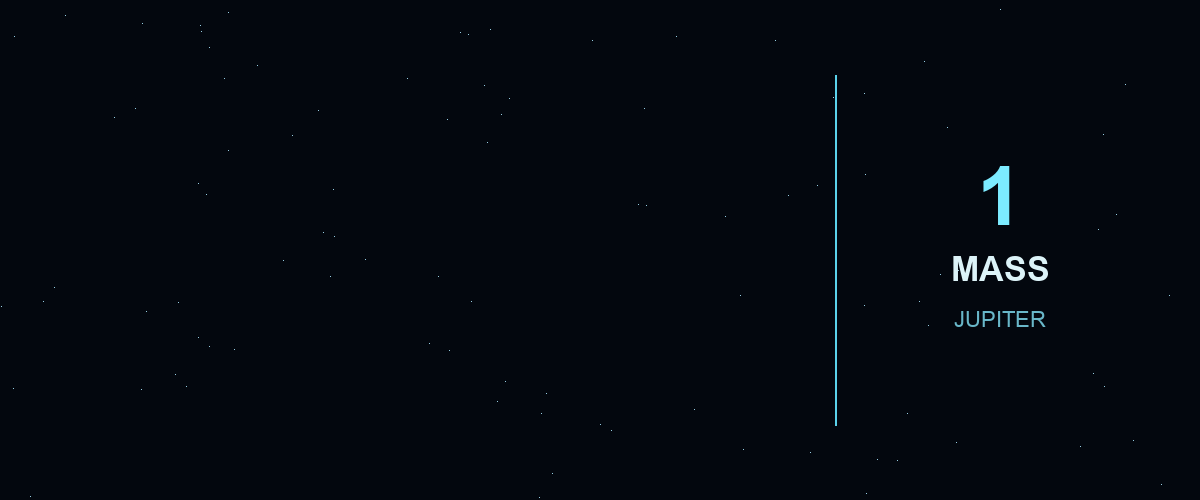

In [6]:
# Change only these constants.
NUMBER = 15
PLANET_NAME = "Jupiter"

from pathlib import Path
import math
import random
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from IPython.display import Image as IPyImage, display

# Animation settings
WIDTH, HEIGHT = 1200, 500
FPS = 24
APPEAR_SECONDS = 0.05
FINAL_HOLD_SECONDS = 3
BACKGROUND = (3, 7, 14)
OUTPUT_DIR = Path.cwd() / "animations" / "mass"
OUTPUT_GIF = OUTPUT_DIR / f"{PLANET_NAME.lower().replace(' ', '_')}_{NUMBER}_masses.gif"

if not isinstance(NUMBER, int) or isinstance(NUMBER, bool) or NUMBER < 1:
    raise ValueError("NUMBER must be a positive integer")

PALETTES = {
    "mercury": ((150, 145, 137), (94, 91, 88)),
    "venus": ((232, 184, 91), (151, 94, 45)),
    "earth": ((55, 145, 220), (39, 112, 67)),
    "mars": ((211, 93, 54), (124, 48, 35)),
    "jupiter": ((220, 177, 126), (143, 92, 66)),
    "saturn": ((225, 201, 137), (157, 126, 73)),
    "uranus": ((128, 215, 224), (66, 151, 172)),
    "neptune": ((64, 100, 218), (37, 54, 139)),
}
PLANET_COLORS = PALETTES.get(PLANET_NAME.strip().lower(), ((105, 205, 230), (42, 105, 145)))

def load_font(size, bold=False):
    candidates = (["/System/Library/Fonts/Supplemental/Arial Bold.ttf", "/System/Library/Fonts/SFNS.ttf"] if bold else ["/System/Library/Fonts/Supplemental/Arial.ttf", "/System/Library/Fonts/SFNS.ttf"])
    candidates += ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"]
    for path in candidates:
        try:
            return ImageFont.truetype(path, size)
        except OSError:
            pass
    return ImageFont.load_default()

FONT_NUMBER = load_font(82, bold=True)
FONT_LABEL = load_font(34, bold=True)
FONT_PLANET = load_font(22)

def ease_out_back(t):
    c1 = 1.70158
    c3 = c1 + 1
    return 1 + c3 * (t - 1) ** 3 + c1 * (t - 1) ** 2

def planet_positions(count):
    cols = min(count, 10)
    rows = math.ceil(count / cols)
    usable_w, usable_h = 730, 350
    gap_x = usable_w / cols
    gap_y = usable_h / max(rows, 1)
    radius = int(max(16, min(42, gap_x * 0.34, gap_y * 0.32)))
    positions = []
    for i in range(count):
        row, col = divmod(i, cols)
        items_this_row = min(cols, count - row * cols)
        row_w = items_this_row * gap_x
        x0 = 55 + (usable_w - row_w) / 2 + gap_x / 2
        positions.append((int(x0 + col * gap_x), int(75 + (row + 0.5) * gap_y), radius))
    return positions

POSITIONS = planet_positions(NUMBER)

def draw_planet(canvas, center, radius, seed):
    if radius <= 1:
        return
    x, y = center
    size = radius * 4
    layer = Image.new("RGBA", (size, size), (0, 0, 0, 0))
    px = layer.load()
    light, dark = PLANET_COLORS
    rng = random.Random(seed)
    bands = [rng.uniform(-1, 1) for _ in range(9)]
    c = size / 2
    r = size * 0.235
    for iy in range(size):
        ny = (iy - c) / r
        if abs(ny) > 1:
            continue
        band = bands[min(8, int((ny + 1) * 4.5))]
        for ix in range(size):
            nx = (ix - c) / r
            d2 = nx * nx + ny * ny
            if d2 <= 1:
                nz = math.sqrt(1 - d2)
                illumination = max(0.12, 0.25 + 0.75 * (0.55 * -nx + 0.35 * -ny + 0.75 * nz))
                texture = 0.92 + 0.08 * math.sin(ny * 18 + band * 4)
                mix = min(1, illumination * texture)
                color = tuple(int(dark[k] + (light[k] - dark[k]) * mix) for k in range(3))
                edge = min(255, int(255 * min(1, (1 - d2) * 9)))
                px[ix, iy] = (*color, edge)
    glow = Image.new("RGBA", layer.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow)
    gd.ellipse((c-r, c-r, c+r, c+r), fill=(*light, 80))
    glow = glow.filter(ImageFilter.GaussianBlur(max(2, radius // 3)))
    canvas.alpha_composite(glow, (x - size // 2, y - size // 2))
    canvas.alpha_composite(layer, (x - size // 2, y - size // 2))

def render_frame(frame_index):
    image = Image.new("RGBA", (WIDTH, HEIGHT), (*BACKGROUND, 255))
    draw = ImageDraw.Draw(image)
    # Subtle deterministic star field.
    stars = random.Random(42)
    for _ in range(95):
        sx, sy = stars.randrange(WIDTH), stars.randrange(HEIGHT)
        a = stars.randrange(35, 115)
        draw.point((sx, sy), fill=(150, 205, 225, a))
    appearing = min(NUMBER, frame_index // FRAMES_PER_PLANET + 1)
    for i in range(appearing):
        x, y, radius = POSITIONS[i]
        age = (frame_index - i * FRAMES_PER_PLANET) / FRAMES_PER_PLANET
        scale = max(0.0, min(1.12, ease_out_back(max(0.0, min(1.0, age)))))
        draw_planet(image, (x, y), max(1, int(radius * scale)), i + 17)
    divider_x = 835
    draw.line((divider_x, 75, divider_x, HEIGHT - 75), fill=(91, 210, 235, 90), width=2)
    count_text = str(appearing)
    count_box = draw.textbbox((0, 0), count_text, font=FONT_NUMBER)
    draw.text((1000 - (count_box[2] - count_box[0]) / 2, 150), count_text, font=FONT_NUMBER, fill=(124, 235, 255, 255))
    label = "MASS" if appearing == 1 else "MASSES"
    label_box = draw.textbbox((0, 0), label, font=FONT_LABEL)
    draw.text((1000 - (label_box[2] - label_box[0]) / 2, 250), label, font=FONT_LABEL, fill=(220, 243, 248, 240))
    planet_label = PLANET_NAME.upper()
    planet_box = draw.textbbox((0, 0), planet_label, font=FONT_PLANET)
    draw.text((1000 - (planet_box[2] - planet_box[0]) / 2, 307), planet_label, font=FONT_PLANET, fill=(105, 183, 201, 220))
    return image.convert("RGB")

FRAMES_PER_PLANET = max(1, round(FPS * APPEAR_SECONDS))
TOTAL_FRAMES = NUMBER * FRAMES_PER_PLANET + round(FPS * FINAL_HOLD_SECONDS)
frames = [render_frame(i) for i in range(TOTAL_FRAMES)]
OUTPUT_GIF.parent.mkdir(parents=True, exist_ok=True)
frames[0].save(OUTPUT_GIF, save_all=True, append_images=frames[1:], duration=round(1000 / FPS), loop=0, optimize=False)
print(f"Saved: {OUTPUT_GIF.resolve()}")
display(IPyImage(filename=str(OUTPUT_GIF.resolve())))


Saved: /Users/mloktionov/Projects/IncusLuminis/products/nebulacast/nebulacast-content/content/papers/shared/animations/mass/black_hole_mass_gap.gif


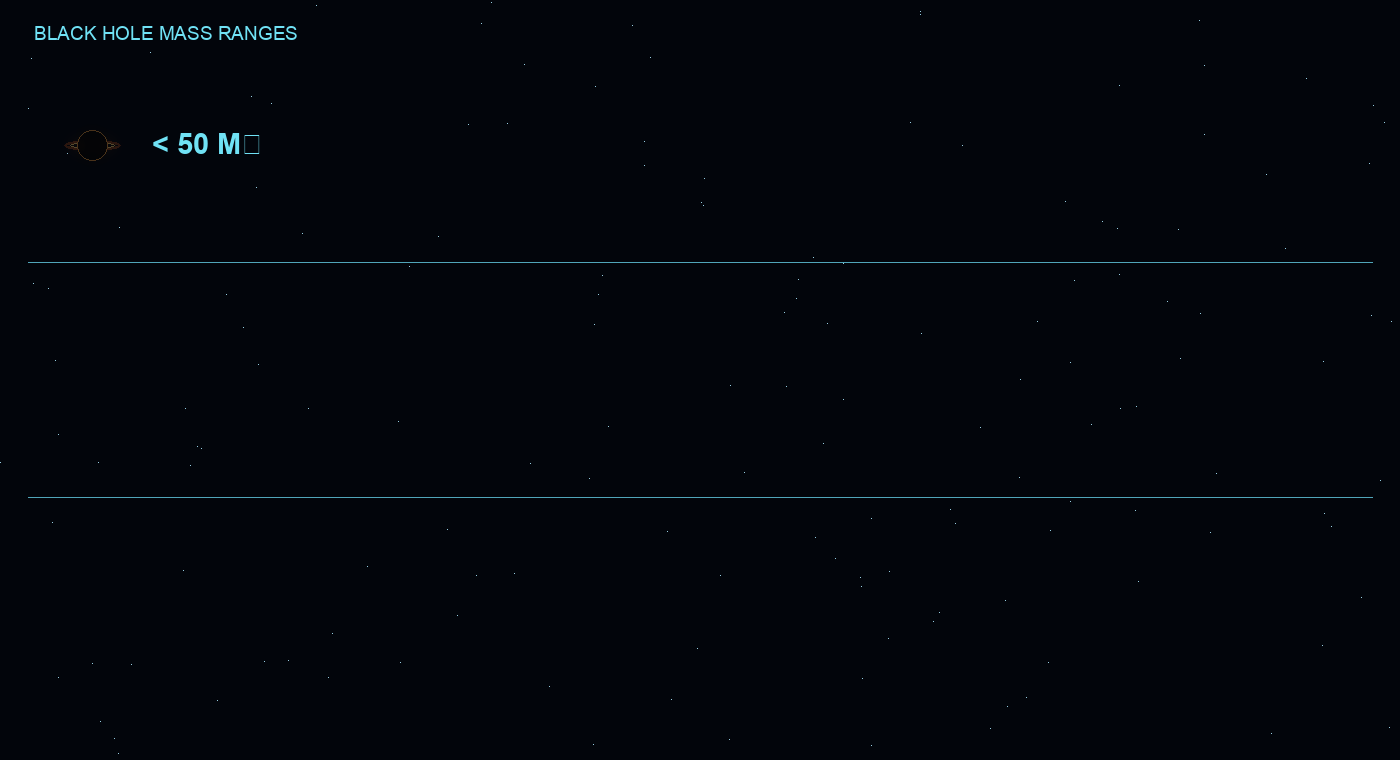

In [4]:
# Black-hole mass ranges — animated explainer
from pathlib import Path
import math
import random
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from IPython.display import Image as IPyImage, display

# Change these constants to tune timing and quantities.
ROW_1_SUNS = 30
ROW_2_SUNS = 50
ROW_3_SUNS = 100
SUNS_PER_FRAME = 5       # Larger = more suns appear at once
SUN_APPEAR_EVERY_FRAMES = 1  # Larger = longer pause between batches
FPS = 24
BLACK_HOLE_APPEAR_FRAMES = 7
PAUSE_BETWEEN_ROWS = 5
FINAL_HOLD_SECONDS = 2.0

WIDTH, HEIGHT = 1400, 760
OUTPUT_DIR = Path.cwd() / "animations" / "mass"
OUTPUT_GIF = OUTPUT_DIR / "black_hole_mass_gap.gif"
BG = (2, 5, 11)
CYAN = (112, 226, 245)
RED = (235, 42, 55)
ROW_COUNTS = (ROW_1_SUNS, ROW_2_SUNS, ROW_3_SUNS)
ROW_LABELS = ("< 50 M☉", "< 130 M☉", "> 130 M☉")
ROW_Y = (145, 380, 615)

if any(not isinstance(n, int) or isinstance(n, bool) or n < 1 for n in ROW_COUNTS):
    raise ValueError("All row counts must be positive integers")
if SUNS_PER_FRAME < 1:
    raise ValueError("SUNS_PER_FRAME must be at least 1")
if SUN_APPEAR_EVERY_FRAMES < 1:
    raise ValueError("SUN_APPEAR_EVERY_FRAMES must be at least 1")

def load_font(size, bold=False):
    paths = (["/System/Library/Fonts/Supplemental/Arial Bold.ttf"] if bold else ["/System/Library/Fonts/Supplemental/Arial.ttf"])
    paths += ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"]
    for path in paths:
        try:
            return ImageFont.truetype(path, size)
        except OSError:
            pass
    return ImageFont.load_default()

FONT_LABEL = load_font(29, bold=True)
FONT_FORBIDDEN = load_font(58, bold=True)
FONT_TITLE = load_font(19)

def ease_out(t):
    t = max(0.0, min(1.0, t))
    return 1 - (1 - t) ** 3

def make_background():
    image = Image.new("RGBA", (WIDTH, HEIGHT), (*BG, 255))
    draw = ImageDraw.Draw(image)
    rng = random.Random(2026)
    for _ in range(150):
        x, y = rng.randrange(WIDTH), rng.randrange(HEIGHT)
        a = rng.randrange(25, 100)
        draw.point((x, y), fill=(150, 205, 225, a))
    draw.text((34, 22), "BLACK HOLE MASS RANGES", font=FONT_TITLE, fill=(*CYAN, 155))
    for y in (262, 497):
        draw.line((28, y, WIDTH - 28, y), fill=(80, 165, 185, 35), width=1)
    return image

BACKGROUND = make_background()

def draw_black_hole(image, y, scale=1.0, alpha=255):
    cx, size = 92, 126
    layer = Image.new("RGBA", (size, size), (0, 0, 0, 0))
    d = ImageDraw.Draw(layer)
    c = size // 2
    r = max(1, int(43 * scale))
    # Accretion disk and hot inner rim.
    d.ellipse((c-r-13, c-r//3, c+r+13, c+r//3), outline=(255, 111, 35, int(alpha * 0.42)), width=max(1, int(9 * scale)))
    d.ellipse((c-r-7, c-r//4, c+r+7, c+r//4), outline=(255, 218, 116, int(alpha * 0.85)), width=max(1, int(4 * scale)))
    d.ellipse((c-r, c-r, c+r, c+r), fill=(0, 0, 0, alpha), outline=(255, 170, 70, int(alpha * 0.75)), width=max(1, int(3 * scale)))
    glow = layer.filter(ImageFilter.GaussianBlur(8))
    image.alpha_composite(glow, (cx-size//2, y-size//2))
    image.alpha_composite(layer, (cx-size//2, y-size//2))

def sun_positions(count, y):
    x0, x1 = 265, WIDTH - 35
    cols = min(25, count)
    rows = math.ceil(count / cols)
    gap_x = (x1 - x0) / max(cols, 1)
    gap_y = min(35, 150 / max(rows, 1))
    positions = []
    for i in range(count):
        row, col = divmod(i, cols)
        items = min(cols, count - row * cols)
        row_width = items * gap_x
        start = x0 + ((x1 - x0) - row_width) / 2 + gap_x / 2
        py = y + (row - (rows - 1) / 2) * gap_y
        positions.append((int(start + col * gap_x), int(py)))
    return positions

SUN_POSITIONS = tuple(sun_positions(n, y) for n, y in zip(ROW_COUNTS, ROW_Y))

def draw_sun(image, x, y, scale=1.0):
    draw = ImageDraw.Draw(image)
    r = max(1, int(8 * scale))
    glow_r = max(r + 1, int(13 * scale))
    draw.ellipse((x-glow_r, y-glow_r, x+glow_r, y+glow_r), fill=(255, 145, 25, 32))
    draw.ellipse((x-r, y-r, x+r, y+r), fill=(255, 205, 75, 255), outline=(255, 239, 175, 255), width=1)
    if r >= 5:
        draw.ellipse((x-r//2, y-r//2, x, y), fill=(255, 245, 190, 210))

# Timeline: row 1, row 3, then the forbidden row 2.
ORDER = (0, 2, 1)
events = {}
cursor = 0
for row_index in ORDER:
    bh_start = cursor
    fill_start = bh_start + BLACK_HOLE_APPEAR_FRAMES
    fill_frames = math.ceil(ROW_COUNTS[row_index] / SUNS_PER_FRAME) * SUN_APPEAR_EVERY_FRAMES
    fill_end = fill_start + fill_frames
    events[row_index] = (bh_start, fill_start, fill_end)
    cursor = fill_end + PAUSE_BETWEEN_ROWS
CROSS_START = cursor
CROSS_FRAMES = 12
TOTAL_FRAMES = CROSS_START + CROSS_FRAMES + round(FPS * FINAL_HOLD_SECONDS)

def render_frame(frame_index):
    image = BACKGROUND.copy()
    draw = ImageDraw.Draw(image)
    for row_index in range(3):
        bh_start, fill_start, fill_end = events[row_index]
        if frame_index < bh_start:
            continue
        bh_t = ease_out((frame_index - bh_start + 1) / BLACK_HOLE_APPEAR_FRAMES)
        draw_black_hole(image, ROW_Y[row_index], bh_t, int(255 * bh_t))
        label = ROW_LABELS[row_index]
        label_alpha = int(255 * bh_t)
        draw.text((152, ROW_Y[row_index] - 18), label, font=FONT_LABEL, fill=(*CYAN, label_alpha))
        fill_step = max(0, (frame_index - fill_start) // SUN_APPEAR_EVERY_FRAMES + 1)
        visible = min(ROW_COUNTS[row_index], fill_step * SUNS_PER_FRAME)
        for i in range(visible):
            x, y = SUN_POSITIONS[row_index][i]
            reveal_frame = fill_start + (i // SUNS_PER_FRAME) * SUN_APPEAR_EVERY_FRAMES
            local_age = frame_index - reveal_frame
            draw_sun(image, x, y, ease_out((local_age + 1) / 4))
    if frame_index >= CROSS_START:
        t = ease_out((frame_index - CROSS_START + 1) / CROSS_FRAMES)
        x0, x1 = 245, WIDTH - 24
        y0, y1 = ROW_Y[1] - 83, ROW_Y[1] + 83
        # Draw both diagonals progressively.
        draw.line((x0, y0, x0 + (x1-x0)*t, y0 + (y1-y0)*t), fill=(*RED, 235), width=10)
        draw.line((x1, y0, x1 - (x1-x0)*t, y0 + (y1-y0)*t), fill=(*RED, 235), width=10)
        if t > 0.55:
            text = "FORBIDDEN"
            box = draw.textbbox((0, 0), text, font=FONT_FORBIDDEN, stroke_width=2)
            tw, th = box[2] - box[0], box[3] - box[1]
            tx, ty = 820 - tw / 2, ROW_Y[1] - th / 2 - 8
            draw.rounded_rectangle((tx-20, ty-10, tx+tw+20, ty+th+14), radius=10, fill=(3, 5, 10, 220), outline=(*RED, 245), width=3)
            draw.text((tx, ty), text, font=FONT_FORBIDDEN, fill=(255, 235, 235, 255), stroke_width=2, stroke_fill=RED)
    return image.convert("RGB")

frames = [render_frame(i) for i in range(TOTAL_FRAMES)]
OUTPUT_GIF.parent.mkdir(parents=True, exist_ok=True)
frames[0].save(OUTPUT_GIF, save_all=True, append_images=frames[1:], duration=round(1000/FPS), loop=0, optimize=False)
print(f"Saved: {OUTPUT_GIF.resolve()}")
display(IPyImage(filename=str(OUTPUT_GIF.resolve())))
